# Carseats Data Management, Wrangling, and Regression in Python

## Project Overview

This notebook rewrites the original **R / ISLR2 Carseats analysis in Python**.

The project covers:

- loading the Carseats dataset
- inspecting rows, columns, and data types
- checking missing values and duplicate records
- identifying the maximum sales value
- identifying stores with Sales above 12
- creating a `HighSales` variable
- reviewing categorical variables
- fitting a multiple linear regression model
- interpreting the business meaning of the regression coefficients
- creating simple visualizations for sales, price, and shelf location

### Main Results from the Original Analysis

- **400 stores**
- **11 original variables**
- **0 missing values**
- Maximum Sales = **16.27**
- Stores with Sales > 12 = **27**
- Regression R² = **0.5734**
- Adjusted R² = **0.5680**

The regression model is:

**Sales ~ Price + Urban + US + ShelveLoc**

# Part 1 — Install / Import Libraries

## 1. Required Python Packages

The notebook uses:

- `pandas` for data management
- `numpy` for numerical work
- `matplotlib` for charts
- `statsmodels` for regression

If you do not already have them installed, run:

```python
%pip install pandas numpy matplotlib statsmodels
```

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from IPython.display import display

pd.set_option(
    "display.max_columns",
    50
)

pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.3f}"
)

# Part 2 — Load the Carseats Dataset

## 2. Load from a Local CSV or the ISLR Dataset Repository

The original R code loads `Carseats` from the `ISLR2` package.

For Python, the notebook first looks for a local file:

- `Carseats.csv`
- `data/Carseats.csv`

If neither exists, it attempts to load the dataset through `statsmodels.get_rdataset`.

> If you are working offline, place `Carseats.csv` beside the notebook or in the `data/` folder.

In [2]:
candidate_files = [
    Path("Carseats.csv"),
    Path("data/Carseats.csv"),
]

local_file = next(
    (
        path
        for path in candidate_files
        if path.exists()
    ),
    None,
)

if local_file is not None:
    Carseats = pd.read_csv(
        local_file
    )

    # Some public Carseats CSV files include
    # an unnamed row-number column.
    unnamed_columns = [
        column
        for column in Carseats.columns
        if str(column).startswith("Unnamed")
    ]

    if unnamed_columns:
        Carseats = Carseats.drop(
            columns=unnamed_columns
        )

    print(
        "Loaded local dataset:",
        local_file
    )

else:
    from statsmodels.datasets import get_rdataset

    Carseats = get_rdataset(
        "Carseats",
        "ISLR"
    ).data

    print(
        "Loaded Carseats from the "
        "R datasets repository."
    )

Loaded Carseats from the R datasets repository.


# Part 3 — Inspect the Dataset

## 3. Check Dataset Dimensions

The original R analysis reports **400 observations and 11 variables**.

In [3]:
print(
    "Rows:",
    Carseats.shape[0]
)

print(
    "Columns:",
    Carseats.shape[1]
)

Rows: 400
Columns: 11


## 4. Preview the First Rows

In [4]:
display(
    Carseats.head()
)

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.500,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.220,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.060,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.400,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.150,141,64,3,340,128,Bad,38,13,Yes,No


## 5. Review Data Types

The dataset contains:

### Numeric variables
- Sales
- CompPrice
- Income
- Advertising
- Population
- Price
- Age
- Education

### Categorical variables
- ShelveLoc
- Urban
- US

In [5]:
data_types = pd.DataFrame({
    "Column": Carseats.columns,
    "Data_Type": (
        Carseats.dtypes
        .astype(str)
        .values
    ),
})

display(
    data_types
)

,Column,Data_Type
0,Sales,float64
1,CompPrice,int64
2,Income,int64
3,Advertising,int64
4,Population,int64
5,Price,int64
6,ShelveLoc,str
7,Age,int64
8,Education,int64
9,Urban,str


# Part 4 — Data Quality Checks

## 6. Check Missing Values

The original R output found **no missing values**.

In [6]:
missing_values = (
    Carseats
    .isna()
    .sum()
    .to_frame(
        "Missing_Values"
    )
)

missing_values[
    "Missing_Percent"
] = (
    missing_values[
        "Missing_Values"
    ]
    / len(Carseats)
    * 100
)

display(
    missing_values
)

print(
    "Total missing cells:",
    int(
        Carseats
        .isna()
        .sum()
        .sum()
    )
)

,Missing_Values,Missing_Percent
Sales,0,0.000
CompPrice,0,0.000
Income,0,0.000
Advertising,0,0.000
Population,0,0.000
Price,0,0.000
ShelveLoc,0,0.000
Age,0,0.000
Education,0,0.000
Urban,0,0.000


Total missing cells: 0


## 7. Check Duplicate Rows

Duplicate records were not explicitly highlighted in the original R output, so this Python version adds the check as a good data-management practice.

In [7]:
duplicate_rows = int(
    Carseats
    .duplicated()
    .sum()
)

print(
    "Exact duplicate rows:",
    duplicate_rows
)

Exact duplicate rows: 0


## 8. Check Categorical Values for Inconsistent Formats

This confirms that category labels are consistent.

In [8]:
categorical_columns = [
    "ShelveLoc",
    "Urban",
    "US",
]

for column in categorical_columns:
    print(
        f"\n{column}:"
    )

    print(
        sorted(
            Carseats[
                column
            ]
            .dropna()
            .astype(str)
            .str.strip()
            .unique()
        )
    )


ShelveLoc:
['Bad', 'Good', 'Medium']

Urban:
['No', 'Yes']

US:
['No', 'Yes']


## 9. Standardize Categorical Text

Remove hidden spaces so values such as `Yes` and `Yes ` are not treated as different categories.

In [9]:
for column in categorical_columns:
    Carseats[column] = (
        Carseats[column]
        .astype(str)
        .str.strip()
    )

# Part 5 — Sales Exploration

## 10. Sort Sales from Highest to Lowest

In [10]:
sorted_sales = (
    Carseats["Sales"]
    .sort_values(
        ascending=False
    )
)

display(
    sorted_sales.head(10)
)

376   16.270
316   15.630
25    14.900
367   14.370
18    13.910
30    13.550
352   13.440
68    13.390
357   13.360
193   13.280
Name: Sales, dtype: float64

## 11. Find the Maximum Sales Value

The original R analysis found a maximum Sales value of **16.27**.

In [11]:
max_sales_value = (
    Carseats["Sales"]
    .max()
)

print(
    "Maximum Sales:",
    max_sales_value
)

max_sales_store = (
    Carseats[
        Carseats["Sales"]
        == max_sales_value
    ]
)

display(
    max_sales_store
)

Maximum Sales: 16.27


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
376,16.270,141,60,19,319,92,Good,44,11,Yes,Yes


## 12. Identify Stores with Sales Greater Than 12

The original analysis found **27 stores** above this threshold.

In [12]:
high_sales_stores = (
    Carseats[
        Carseats["Sales"] > 12
    ]
    .copy()
)

print(
    "Stores with Sales > 12:",
    len(
        high_sales_stores
    )
)

display(
    high_sales_stores
)

Stores with Sales > 12: 27


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
17,12.290,147,74,13,251,131,Good,52,10,Yes,Yes
18,13.910,110,110,0,408,68,Good,46,17,No,Yes
21,12.130,134,29,12,239,109,Good,62,18,No,Yes
25,14.900,139,32,0,176,82,Good,54,11,No,No
30,13.550,125,94,0,447,89,Good,30,12,Yes,No
46,12.440,127,90,14,16,70,Medium,48,15,No,Yes
68,13.390,149,69,20,366,134,Good,60,13,Yes,Yes
73,12.610,118,90,10,54,104,Good,31,11,No,Yes
98,12.490,122,77,24,382,127,Good,36,16,No,Yes
139,12.300,146,62,10,310,94,Medium,30,13,No,Yes


# Part 6 — Feature Engineering

## 13. Create the HighSales Variable

The original R code defines:

- `Yes` when Sales > 12
- `No` otherwise

This converts a continuous sales measure into a simple high-sales classification field.

In [13]:
Carseats[
    "HighSales"
] = np.where(
    Carseats["Sales"] > 12,
    "Yes",
    "No",
)

display(
    Carseats[
        [
            "Sales",
            "HighSales",
        ]
    ].head()
)

,Sales,HighSales
0,9.500,No
1,11.220,No
2,10.060,No
3,7.400,No
4,4.150,No


## 14. Count HighSales Categories

In [14]:
high_sales_counts = (
    Carseats[
        "HighSales"
    ]
    .value_counts()
    .rename_axis(
        "HighSales"
    )
    .reset_index(
        name="Store_Count"
    )
)

display(
    high_sales_counts
)

,HighSales,Store_Count
0,No,373
1,Yes,27


## 15. Optional Numeric HighSales Variable

Some machine-learning algorithms work more naturally with 0/1 labels.

This creates:

- 1 = Sales > 12
- 0 = Sales ≤ 12

In [15]:
Carseats[
    "HighSales_Flag"
] = np.where(
    Carseats["Sales"] > 12,
    1,
    0,
)

display(
    Carseats[
        [
            "Sales",
            "HighSales",
            "HighSales_Flag",
        ]
    ].head()
)

,Sales,HighSales,HighSales_Flag
0,9.500,No,0
1,11.220,No,0
2,10.060,No,0
3,7.400,No,0
4,4.150,No,0


# Part 7 — Review Shelf Location

## 16. Inspect ShelveLoc Categories

The original R factor contained:

- Bad
- Good
- Medium

In [16]:
shelf_levels = (
    sorted(
        Carseats[
            "ShelveLoc"
        ].unique()
    )
)

print(
    "ShelveLoc levels:",
    shelf_levels
)

ShelveLoc levels: ['Bad', 'Good', 'Medium']


## 17. Average Sales by Shelf Location

This provides a simple business comparison before regression.

In [17]:
sales_by_shelf = (
    Carseats
    .groupby(
        "ShelveLoc"
    )["Sales"]
    .agg(
        [
            "count",
            "mean",
            "median",
        ]
    )
    .sort_values(
        "mean",
        ascending=False,
    )
)

display(
    sales_by_shelf.round(2)
)

,count,mean,median
ShelveLoc,,,
Good,85,10.210,10.500
Medium,219,7.310,7.380
Bad,96,5.520,5.210


# Part 8 — Multiple Linear Regression

## 18. Fit the Same Model as the R Code

The original R model is:

```text
Sales ~ Price + Urban + US + ShelveLoc
```

Python uses treatment coding for the categorical fields.

Reference groups:

- Urban = No
- US = No
- ShelveLoc = Bad

In [18]:
model = smf.ols(
    formula=(
        'Sales ~ Price '
        '+ C(Urban, Treatment(reference="No")) '
        '+ C(US, Treatment(reference="No")) '
        '+ C(ShelveLoc, Treatment(reference="Bad"))'
    ),
    data=Carseats,
).fit()

print(
    model.summary()
)

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.573
Model:                            OLS   Adj. R-squared:                  0.568
Method:                 Least Squares   F-statistic:                     105.9
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           1.20e-70
Time:                        00:01:18   Log-Likelihood:                -811.98
No. Observations:                 400   AIC:                             1636.
Df Residuals:                     394   BIC:                             1660.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

# Part 9 — Regression Results

## 19. Create a Clean Coefficient Table

In [19]:
coefficient_table = pd.DataFrame({
    "Coefficient":
        model.params.index,
    "Estimate":
        model.params.values,
    "Std_Error":
        model.bse.values,
    "T_Value":
        model.tvalues.values,
    "P_Value":
        model.pvalues.values,
})

display(
    coefficient_table.round(4)
)

,Coefficient,Estimate,Std_Error,T_Value,P_Value
0,Intercept,11.320,0.515,21.999,0.000
1,"C(Urban, Treatment(reference=""No""))[T.Yes]",0.245,0.205,1.199,0.231
2,"C(US, Treatment(reference=""No""))[T.Yes]",1.002,0.195,5.137,0.000
3,"C(ShelveLoc, Treatment(reference=""Bad""))[T.Good]",4.853,0.278,17.458,0.000
4,"C(ShelveLoc, Treatment(reference=""Bad""))[T.Med...",1.913,0.228,8.393,0.000
5,Price,-0.058,0.004,-14.731,0.000


## 20. Model Performance

In [20]:
model_performance = pd.DataFrame({
    "Metric": [
        "R-squared",
        "Adjusted R-squared",
        "Residual standard error",
        "F-statistic",
        "F-test p-value",
    ],
    "Value": [
        model.rsquared,
        model.rsquared_adj,
        np.sqrt(
            model.mse_resid
        ),
        model.fvalue,
        model.f_pvalue,
    ],
})

display(
    model_performance
)

,Metric,Value
0,R-squared,0.573
1,Adjusted R-squared,0.568
2,Residual standard error,1.856
3,F-statistic,105.908
4,F-test p-value,0.000


# Part 10 — Business Interpretation

## 21. Interpret the Original Regression Findings

The original R model produced approximately:

| Variable | Estimate | Interpretation |
|---|---:|---|
| Intercept | 11.320 | Baseline predicted sales |
| Price | **-0.058** | Higher price is associated with lower sales |
| Urban = Yes | 0.245 | Small positive effect; not statistically significant |
| US = Yes | **1.002** | US stores have higher predicted sales, holding other variables constant |
| ShelveLoc = Good | **4.853** | Good shelf location has a very large positive relationship with sales |
| ShelveLoc = Medium | **1.913** | Medium shelf location performs better than Bad |

### Strongest Insight

Shelf location has the largest estimated effect in the model.

Compared with a Bad shelf location:

- Good shelving increases predicted Sales by about **4.85 thousand units**
- Medium shelving increases predicted Sales by about **1.91 thousand units**

### Price Effect

The Price coefficient is approximately **-0.058**.

Holding the other variables constant, a $1 increase in Price is associated with about **0.058 thousand fewer units sold**.

### Urban Status

Urban location has a p-value of about **0.231** in the original analysis.

This means the model does not provide strong evidence that Urban vs. non-Urban location independently affects Sales after controlling for Price, US status, and ShelveLoc.

### Model Fit

The original model explains about **57.3%** of the variation in Sales.

That is meaningful explanatory power, but substantial variation remains unexplained.

# Part 11 — Visualizations

## 22. Sales Distribution

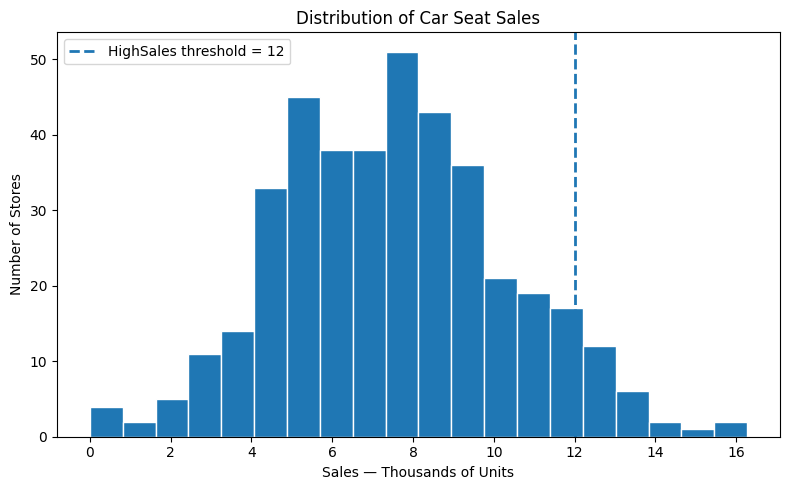

In [21]:
plt.figure(
    figsize=(8, 5)
)

plt.hist(
    Carseats["Sales"],
    bins=20,
    edgecolor="white",
)

plt.axvline(
    12,
    linestyle="--",
    linewidth=2,
    label="HighSales threshold = 12",
)

plt.title(
    "Distribution of Car Seat Sales"
)
plt.xlabel(
    "Sales — Thousands of Units"
)
plt.ylabel(
    "Number of Stores"
)
plt.legend()
plt.tight_layout()
plt.show()

## 23. Average Sales by Shelf Location

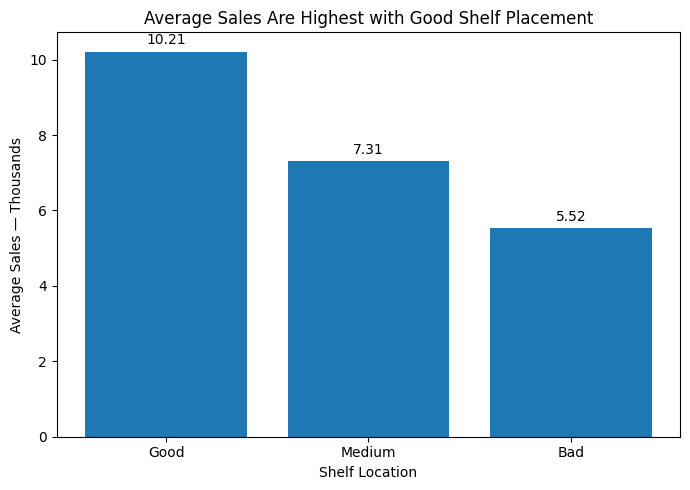

In [22]:
shelf_plot = (
    Carseats
    .groupby(
        "ShelveLoc"
    )["Sales"]
    .mean()
    .sort_values(
        ascending=False
    )
)

plt.figure(
    figsize=(7, 5)
)

bars = plt.bar(
    shelf_plot.index,
    shelf_plot.values,
)

plt.bar_label(
    bars,
    labels=[
        f"{value:.2f}"
        for value
        in shelf_plot.values
    ],
    padding=3,
)

plt.title(
    "Average Sales Are Highest with Good Shelf Placement"
)
plt.xlabel(
    "Shelf Location"
)
plt.ylabel(
    "Average Sales — Thousands"
)
plt.tight_layout()
plt.show()

## 24. Price vs. Sales

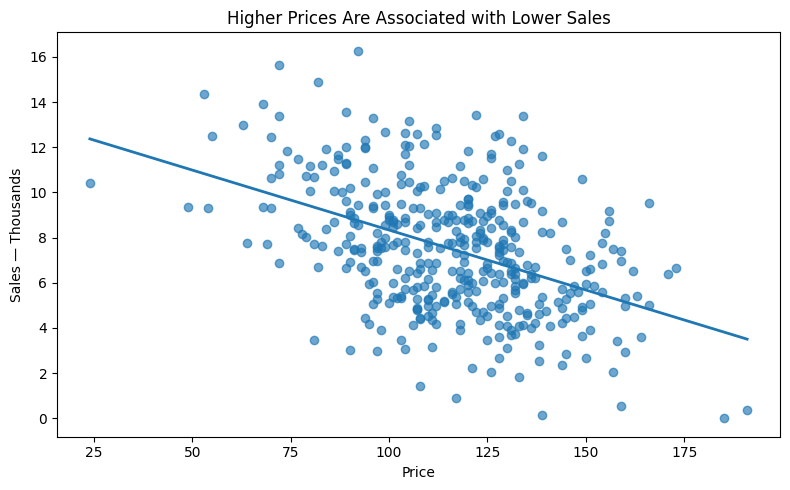

In [23]:
plt.figure(
    figsize=(8, 5)
)

plt.scatter(
    Carseats["Price"],
    Carseats["Sales"],
    alpha=0.65,
)

price_line = np.linspace(
    Carseats["Price"].min(),
    Carseats["Price"].max(),
    100,
)

simple_price_model = np.polyfit(
    Carseats["Price"],
    Carseats["Sales"],
    1,
)

plt.plot(
    price_line,
    (
        simple_price_model[0]
        * price_line
        + simple_price_model[1]
    ),
    linewidth=2,
)

plt.title(
    "Higher Prices Are Associated with Lower Sales"
)
plt.xlabel(
    "Price"
)
plt.ylabel(
    "Sales — Thousands"
)
plt.tight_layout()
plt.show()

## 25. High-Sales Store Count

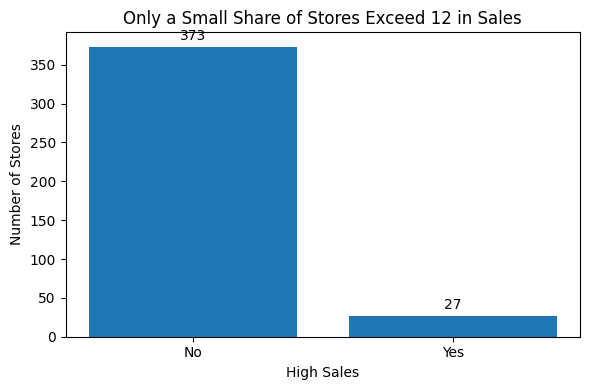

In [24]:
high_sales_plot = (
    Carseats[
        "HighSales"
    ]
    .value_counts()
)

plt.figure(
    figsize=(6, 4)
)

bars = plt.bar(
    high_sales_plot.index,
    high_sales_plot.values,
)

plt.bar_label(
    bars,
    padding=3,
)

plt.title(
    "Only a Small Share of Stores Exceed 12 in Sales"
)
plt.xlabel(
    "High Sales"
)
plt.ylabel(
    "Number of Stores"
)
plt.tight_layout()
plt.show()

# Part 12 — Export the Cleaned Data and Results

## 26. Create an Output Folder

In [25]:
OUTPUT_DIR = Path(
    "outputs"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    OUTPUT_DIR.resolve()
)

C:\Users\tooko\Downloads\outputs


## 27. Export the Enhanced Dataset

In [26]:
Carseats.to_csv(
    OUTPUT_DIR
    / "carseats_cleaned_with_highsales.csv",
    index=False,
)

## 28. Export Regression Results

In [27]:
coefficient_table.to_csv(
    OUTPUT_DIR
    / "regression_coefficients.csv",
    index=False,
)

model_performance.to_csv(
    OUTPUT_DIR
    / "regression_model_performance.csv",
    index=False,
)

high_sales_stores.to_csv(
    OUTPUT_DIR
    / "high_sales_stores.csv",
    index=False,
)

print(
    "Outputs saved successfully."
)

Outputs saved successfully.


# Final Takeaway

This project demonstrates a complete introductory data-management and regression workflow.

The main findings are:

1. The Carseats dataset contains **400 stores and no missing values**.
2. Maximum Sales is **16.27**.
3. Only **27 stores** have Sales above 12.
4. Higher Price is associated with lower Sales.
5. Good and Medium shelf locations strongly outperform Bad shelf locations.
6. US stores have higher predicted Sales after controlling for Price and shelf location.
7. Urban status is not statistically significant in this model.
8. The regression explains about **57% of total Sales variation**.

The most useful business insight is:

> **Shelf placement and pricing appear much more important to sales performance than whether a store is simply located in an urban area.**